# E2: Encoder-WER Correlation Analysis (PoC)

**Goal:** Test whether encoder-space distance between canonical English and L2 speech predicts transcription error (WER).

**Hypothesis:** Accented speech has encoder representations further from canonical English, and this distance correlates with higher WER.

**Approach:**
- Select 1 male speaker per L1 + English reference (RMS from CMU)
- For each prompt utterance pair (English, L1 speaker):
  - Load frame-level encoder embeddings
  - DTW align the utterances
  - Compute mean frame-wise cosine distance
- Correlate distance with Whisper WER

## Cell 1: Setup & Imports

In [ ]:
import torch
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from dtaidistance import dtw_ndim
import matplotlib.pyplot as plt
import seaborn as sns
import sys
ROOT = '/rds/general/user/tsv22/home/accent-robust-asr'
sys.path.insert(0, ROOT)
from src.config import TEST_SPEAKERS, SPEAKER_L1

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Use test speakers (one per L1, mix of genders - will clean up later)
SELECTED_SPEAKERS = {SPEAKER_L1[spk]: spk for spk in TEST_SPEAKERS}

PROCESSED_DIR = Path(f"{ROOT}/data/processed")
MAPPING_CACHE = f"{ROOT}/src/analysis/cache/utterance_mapping.json"
WER_CSV = f"{ROOT}/results/model_perf_comparison/whisfusion_finetuned_predictions.csv"

print("✓ Setup complete")
print(f"  Selected speakers: {SELECTED_SPEAKERS}")
print(f"  Data dir: {PROCESSED_DIR}")
print(f"  WER file: {WER_CSV}")

✓ Setup complete
  Selected speakers: {'Chinese': 'BWC', 'Hindi': 'SVBI', 'Vietnamese': 'HQTV', 'English': 'BDL', 'Spanish': 'EBVS', 'Arabic': 'ZHAA', 'Korean': 'HJK'}
  Data dir: /rds/general/user/tsv22/home/accent-robust-asr/data/processed
  WER file: /rds/general/user/tsv22/home/accent-robust-asr/results/model_perf_comparison/whisfusion_finetuned_predictions.csv


## Cell 2: Build/Load Utterance Mapping

In [ ]:
def parse_lab_file(lab_path: str):
    """Parse CMU ARCTIC .lab files to extract phone segments with timing."""
    segments = []
    with open(lab_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    start_time = float(parts[0])
                    phone_label = parts[2]
                    if phone_label.lower() != 'pau':  # skip silence
                        segments.append((start_time, phone_label))
                except (ValueError, IndexError):
                    continue
    
    if not segments:
        return []
    
    # Convert to objects with end times
    phone_segments = []
    for i, (start, label) in enumerate(segments):
        end = segments[i+1][0] if i+1 < len(segments) else start + 0.1
        phone_segments.append({
            'label': label.upper(),
            'start': start,
            'end': end,
        })
    return phone_segments


def build_mapping():
    """Scan data/processed/ and map (prompt_id, L1) -> file paths + TextGrid info"""
    from src.utils.textgrid import parse_textgrid

    mapping = {}
    missing_textgrids = []

    # Use absolute paths from ROOT
    L2ARCTIC_ABS = Path(ROOT) / "data" / "l2_arctic"
    CMU_ARCTIC_ABS = Path(ROOT) / "data" / "cmu_arctic"

    for split in ["train", "dev", "test"]:
        split_dir = PROCESSED_DIR / split
        if not split_dir.exists():
            continue

        speaker_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
        for speaker_dir in tqdm(speaker_dirs, desc=f"  {split}"):
            speaker = speaker_dir.name
            l1 = None

            for l1_name, spk in SELECTED_SPEAKERS.items():
                if spk == speaker:
                    l1 = l1_name
                    break

            if l1 is None:
                continue

            for pt_file in speaker_dir.glob("*.pt"):
                parts = pt_file.stem.split("_")
                prompt_id = "_".join(parts[-2:])

                # Find TextGrid or LAB file
                tg_path = None
                speech_end_frame = None

                if l1 == "English":
                    candidate = CMU_ARCTIC_ABS / f"cmu_us_{speaker.lower()}_arctic" / "lab" / f"{prompt_id}.lab"
                else:
                    candidate = L2ARCTIC_ABS / speaker / "textgrid" / f"{prompt_id}.TextGrid"

                if candidate.exists():
                    tg_path = str(candidate)

                # Load TextGrid or LAB to get speech end time
                if tg_path:
                    try:
                        if tg_path.endswith('.TextGrid'):
                            phone_segments = parse_textgrid(tg_path, tier_name='phones')
                            if phone_segments:
                                speech_end_frame = int(phone_segments[-1].end * 50) + 1
                        elif tg_path.endswith('.lab'):
                            phone_segments = parse_lab_file(tg_path)
                            if phone_segments:
                                speech_end_frame = int(phone_segments[-1]['end'] * 50) + 1
                    except Exception as e:
                        missing_textgrids.append((prompt_id, speaker, str(e)))
                else:
                    missing_textgrids.append((prompt_id, speaker, "not found"))

                if prompt_id not in mapping:
                    mapping[prompt_id] = {}

                mapping[prompt_id][l1] = {
                    "speaker": speaker,
                    "path": str(pt_file),
                    "textgrid": tg_path,
                    "speech_end_frame": speech_end_frame,
                }

    # Sanity checks
    print(f"\n✓ Built mapping: {len(mapping)} prompts")
    print(f"  Missing TextGrids/LABs: {len(missing_textgrids)}")
    if missing_textgrids and len(missing_textgrids) <= 10:
        for prompt_id, speaker, reason in missing_textgrids[:5]:
            print(f"    - {prompt_id}/{speaker}: {reason}")

    return mapping

# Load or build mapping (force rebuild to get speech_end_frame populated)
print("Rebuilding mapping with absolute paths to fix TextGrid/LAB loading...")
mapping = build_mapping()
Path(MAPPING_CACHE).parent.mkdir(parents=True, exist_ok=True)
with open(MAPPING_CACHE, 'w') as f:
    json.dump(mapping, f, indent=2)
print(f"✓ Cached to {MAPPING_CACHE}")

# Filter to only prompts with both English and at least one L2 speaker
valid_mapping = {
    pid: l1d for pid, l1d in mapping.items()
    if "English" in l1d and len(l1d) > 1
}
print(f"✓ {len(valid_mapping)} prompts have both English and L2 utterances")

# Show coverage per L1
l1_coverage = {}
for l1_list in valid_mapping.values():
    for l1 in l1_list.keys():
        l1_coverage[l1] = l1_coverage.get(l1, 0) + 1

print(f"\nUtterance coverage per L1:")
for l1 in sorted(l1_coverage.keys()):
    print(f"  {l1:15s}: {l1_coverage[l1]:4d} prompts")

Rebuilding mapping with absolute paths to fix TextGrid/LAB loading...


  test: 100%|██████████| 7/7 [00:55<00:00,  7.91s/it]


✓ Built mapping: 1132 prompts
  Missing TextGrids/LABs: 0
✓ Cached to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/cache/utterance_mapping.json
✓ 1132 prompts have both English and L2 utterances

Utterance coverage per L1:
  Arabic         : 1132 prompts
  Chinese        : 1130 prompts
  English        : 1132 prompts
  Hindi          : 1132 prompts
  Korean         : 1131 prompts
  Spanish        : 1007 prompts
  Vietnamese     : 1132 prompts


## Cell 3: Helper Functions

In [3]:
def load_utterance(path: str) -> np.ndarray:
    """Load and return embeddings tensor (T, 768) as float32 
numpy array"""
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    hidden_states = checkpoint['hidden_states']
    # Convert to float32 (handles bfloat16, float16, etc.)
    hidden_states = hidden_states.to(torch.float32)
    return hidden_states.cpu().numpy() if hasattr(hidden_states,
'numpy') else np.array(hidden_states)


def dtw_align_and_distance(emb_eng: np.ndarray, emb_l2:
np.ndarray) -> float:
    """DTW align two utterances and return mean frame-wise 
cosine distance."""
    from scipy.spatial.distance import cdist

    path = dtw_ndim.warping_path(emb_eng, emb_l2)

    # Extract aligned frames
    path_array = np.array(path)
    eng_frames = emb_eng[path_array[:, 0]]
    l2_frames = emb_l2[path_array[:, 1]]

    # Use scipy's vectorized cosine distance
    distances = cdist(eng_frames, l2_frames, metric='cosine').diagonal()

    return np.mean(distances) if len(distances) > 0 else 1.0


print("✓ Helper functions defined")

✓ Helper functions defined


## Cell 4: Load WER Data

In [4]:
if Path(WER_CSV).exists():
    wer_df = pd.read_csv(WER_CSV)
    print(f"✓ Loaded WER data: {len(wer_df)} rows")
    print(f"Columns: {wer_df.columns.tolist()}")
    print(f"\nFirst 3 rows:")
    print(wer_df.head(3))
    
    # Build lookup: (prompt_id, speaker) -> WER
    # Identify correct column names
    prompt_col = next((c for c in ['prompt_id', 'utterance_id', 'utt_id'] if c in wer_df.columns), None)
    speaker_col = next((c for c in ['speaker', 'spk'] if c in wer_df.columns), None)
    wer_col = next((c for c in ['wer', 'WER', 'utt_wer'] if c in wer_df.columns), None)
    
    print(f"\nUsing columns: prompt_id={prompt_col}, speaker={speaker_col}, wer={wer_col}")
    
    wer_data = {}
    if all([prompt_col, speaker_col, wer_col]):
        # Vectorized approach: drop NaN, then build dict from tuples
        valid_wer_df = wer_df.dropna(subset=[prompt_col, speaker_col, wer_col])
        wer_data = dict(zip(
            zip(valid_wer_df[prompt_col].astype(str), valid_wer_df[speaker_col].astype(str)),
            valid_wer_df[wer_col].astype(float)
        ))
    
    print(f"✓ Indexed WER for {len(wer_data)} (prompt, speaker) pairs")
    if wer_data:
        print(f"  Example: {list(wer_data.items())[0]}")
        print(f"  WER range: {min(wer_data.values()):.2f} - {max(wer_data.values()):.2f}")
else:
    print(f"[WARN] WER file not found: {WER_CSV}")
    wer_data = {}

✓ Loaded WER data: 7796 rows
Columns: ['utterance_id', 'speaker', 'l1', 'wav_path', 'domain', 'text', 'prediction', 'reference_norm', 'prediction_norm', 'ref_num_words', 'utt_wer', 'utt_mer', 'utt_per']

First 3 rows:
   utterance_id speaker       l1                                 wav_path  \
0  arctic_a0001     BWC  Chinese  data/l2_arctic/BWC/wav/arctic_a0001.wav   
1  arctic_a0002     BWC  Chinese  data/l2_arctic/BWC/wav/arctic_a0002.wav   
2  arctic_a0003     BWC  Chinese  data/l2_arctic/BWC/wav/arctic_a0003.wav   

     domain                                               text  \
0  scripted   Author of the danger trail Philip Steels and etc   
1  scripted  Not at this particular case Tom apologized Whi...   
2  scripted  For the twentieth time that evening the two me...   

                                          prediction  \
0   Author of the the trail Philip Philip Steels etc   
1  Not at this particular case Tom apologized Whi...   
2  For the twenti time time that evening

In [ ]:
# Check what paths we're actually looking for
sample_prompt = "arctic_b0187"
speaker_eng = "BDL"  # English speaker
speaker_ar = "ZHAA"  # Arabic speaker

print("Looking for English (CMU):") 
cmu_lab = Path(f"{ROOT}/data/cmu_arctic") / f"cmu_us_{speaker_eng.lower()}_arctic" / "lab" / f"{sample_prompt}.lab"
print(f"  Path: {cmu_lab}")
print(f"  Exists: {cmu_lab.exists()}")
print(f"  Parent exists: {cmu_lab.parent.exists()}")

print("\nLooking for Arabic (L2-ARCTIC):")
l2_tg = Path(f"{ROOT}/data/l2_arctic") / speaker_ar / "textgrid" / f"{sample_prompt}.TextGrid"
print(f"  Path: {l2_tg}")
print(f"  Exists: {l2_tg.exists()}")
print(f"  Parent exists: {l2_tg.parent.exists()}")

# List what's actually there
print(f"\nActual files in L2-ARCTIC/{speaker_ar}/textgrid/:")
import os
tg_dir = Path(f"{ROOT}/data/l2_arctic") / speaker_ar / "textgrid"
if tg_dir.exists():
    files = sorted(os.listdir(tg_dir))[:5]
    print(f"  First 5: {files}")
else:
    print(f"  Directory doesn't exist")

Looking for English (CMU):
  Path: /rds/general/user/tsv22/home/accent-robust-asr/data/cmu_arctic/cmu_us_bdl_arctic/lab/arctic_b0187.lab
  Exists: True
  Parent exists: True

Looking for Arabic (L2-ARCTIC):
  Path: /rds/general/user/tsv22/home/accent-robust-asr/data/l2_arctic/ZHAA/textgrid/arctic_b0187.TextGrid
  Exists: True
  Parent exists: True

Actual files in L2-ARCTIC/ZHAA/textgrid/:
  First 5: ['arctic_a0001.TextGrid', 'arctic_a0002.TextGrid', 'arctic_a0003.TextGrid', 'arctic_a0004.TextGrid', 'arctic_a0005.TextGrid']


In [6]:
# Check if speech_end_frame is actually populated
sample_prompt = list(valid_mapping.keys())[0]
eng_info = valid_mapping[sample_prompt]["English"]
arabic_info = valid_mapping[sample_prompt]["Arabic"]

print(f"Sample prompt: {sample_prompt}")
print(f"English: speech_end_frame={eng_info.get('speech_end_frame')}, textgrid={eng_info.get('textgrid')}")
print(f"Arabic: speech_end_frame={arabic_info.get('speech_end_frame')}, textgrid={arabic_info.get('textgrid')}")

# Load and check raw shape
emb_eng_raw = load_utterance(eng_info["path"])
emb_l2_raw = load_utterance(arabic_info["path"])
print(f"\nRaw shapes: eng={emb_eng_raw.shape}, l2={emb_l2_raw.shape}")

# Check trim values
eng_trim = eng_info.get("speech_end_frame")
l2_trim = arabic_info.get("speech_end_frame")
print(f"Trim frames: eng={eng_trim}, l2={l2_trim}")

if eng_trim:
    eng_duration_sec = eng_trim / 50  # 50Hz frame rate
    eng_duration_ms = eng_duration_sec * 1000
    print(f"After trim: eng would be {emb_eng_raw[:eng_trim].shape}")
    print(f"  Duration: {eng_duration_sec:.2f}s ({eng_duration_ms:.0f}ms)")

if l2_trim:
    l2_duration_sec = l2_trim / 50  # 50Hz frame rate
    l2_duration_ms = l2_duration_sec * 1000
    if eng_trim:
        print(f"  vs Arabic: {l2_duration_sec:.2f}s ({l2_duration_ms:.0f}ms)")

Sample prompt: arctic_a0069
English: speech_end_frame=158, textgrid=/rds/general/user/tsv22/home/accent-robust-asr/data/cmu_arctic/cmu_us_bdl_arctic/lab/arctic_a0069.lab
Arabic: speech_end_frame=161, textgrid=/rds/general/user/tsv22/home/accent-robust-asr/data/l2_arctic/ZHAA/textgrid/arctic_a0069.TextGrid

Raw shapes: eng=(1500, 768), l2=(1500, 768)
Trim frames: eng=158, l2=161
After trim: eng would be (158, 768)
  Duration: 3.16s (3160ms)
  vs Arabic: 3.22s (3220ms)


In [7]:
# Quick profile on a few pairs
import time

print("Profiling DTW + cosine on sample data...")

# Load a couple test utterances
test_path_eng = valid_mapping[list(valid_mapping.keys())[0]]["English"]["path"]
test_path_l2 = valid_mapping[list(valid_mapping.keys())[0]]["Arabic"]["path"]

emb_eng = load_utterance(test_path_eng)
emb_l2 = load_utterance(test_path_l2)

# Trim
eng_trim = valid_mapping[list(valid_mapping.keys())[0]]["English"].get("speech_end_frame")
if eng_trim:
    emb_eng = emb_eng[:eng_trim]
l2_trim = valid_mapping[list(valid_mapping.keys())[0]]["Arabic"].get("speech_end_frame")
if l2_trim:
    emb_l2 = emb_l2[:l2_trim]

print(f"Trimmed shapes: eng={emb_eng.shape}, l2={emb_l2.shape}")

# Profile DTW
start = time.time()
path = dtw_ndim.warping_path(emb_eng, emb_l2)
dtw_time = time.time() - start
print(f"DTW warping_path: {dtw_time*1000:.1f}ms, path length={len(path)}")

# Profile cosine
from scipy.spatial.distance import cdist
start = time.time()
path_array = np.array(path)
eng_frames = emb_eng[path_array[:, 0]]
l2_frames = emb_l2[path_array[:, 1]]
distances = cdist(eng_frames, l2_frames,metric='cosine').diagonal()
cosine_time = time.time() - start
print(f"Cosine distance: {cosine_time*1000:.1f}ms")
print(f"Total per alignment: {(dtw_time + cosine_time)*1000:.1f}ms")

Profiling DTW + cosine on sample data...
Trimmed shapes: eng=(158, 768), l2=(161, 768)
DTW warping_path: 170.0ms, path length=178
Cosine distance: 14.7ms
Total per alignment: 184.7ms


## Cell 5: Compute Encoder Distances

In [9]:
import pickle

DISTANCES_CACHE = Path(f"{ROOT}/src/analysis/results/encoder_wer_distances.pkl")

# Load existing results or start fresh
if DISTANCES_CACHE.exists():
    with open(DISTANCES_CACHE, 'rb') as f:
        results = pickle.load(f)
    print(f"✓ Loaded existing results: {len(results)} pairs")
    computed_prompts = {r["prompt_id"] for r in results}
else:
    results = []
    computed_prompts = set()
    print("Starting fresh distance computation...")

errors = {"missing_file": 0, "load_error": 0, "alignment_error": 0}

prompts_to_compute = sorted(set(valid_mapping.keys()) - computed_prompts)
print(f"  Computing {len(prompts_to_compute)} new prompts")
if computed_prompts:
    print(f"  (skipping {len(computed_prompts)} already done)\n")

for prompt_id in tqdm(prompts_to_compute, desc="Computing distances"):
    l1_dict = valid_mapping[prompt_id]
    
    try:
        # Load English reference
        eng_path = l1_dict["English"]["path"]
        if not Path(eng_path).exists():
            errors["missing_file"] += 1
            continue
        
        emb_eng = load_utterance(eng_path)
        
        # Trim English to speech end (remove padding)
        eng_trim = l1_dict["English"].get("speech_end_frame")
        if eng_trim:
            emb_eng = emb_eng[:eng_trim]
        
        # Compare against each L1 speaker
        for l1, speaker_info in l1_dict.items():
            if l1 == "English":
                continue
            
            l2_path = speaker_info["path"]
            if not Path(l2_path).exists():
                errors["missing_file"] += 1
                continue
            
            try:
                emb_l2 = load_utterance(l2_path)
                
                # Trim L2 to speech end (remove padding)
                l2_trim = speaker_info.get("speech_end_frame")
                if l2_trim:
                    emb_l2 = emb_l2[:l2_trim]
                
            except Exception as e:
                print(f"  [ERROR] Load {l2_path}: {e}")
                errors["load_error"] += 1
                continue
            
            try:
                # DTW align and compute distance
                distance = dtw_align_and_distance(emb_eng, emb_l2)
            except Exception as e:
                print(f"  [ERROR] DTW {prompt_id}/{l1}: {e}")
                errors["alignment_error"] += 1
                continue
            
            # Get WER
            speaker = speaker_info["speaker"]
            wer = wer_data.get((prompt_id, speaker), np.nan)
            
            results.append({
                "prompt_id": prompt_id,
                "L1": l1,
                "speaker": speaker,
                "distance": distance,
                "wer": wer,
            })
    
    except Exception as e:
        print(f"  [ERROR] {prompt_id}: {e}")

# Save all results at end
DISTANCES_CACHE.parent.mkdir(parents=True, exist_ok=True)
with open(DISTANCES_CACHE, 'wb') as f:
    pickle.dump(results, f)

results_df = pd.DataFrame(results)
print(f"\n✓ Computed distances for {len(results_df)} utterance pairs (total)")
print(f"  Cached to: {DISTANCES_CACHE}")
print(f"\nErrors: {errors}")
print(f"\nSample results:")
print(results_df.head(10))
print(f"\nDistance stats:")
print(results_df["distance"].describe())
print(f"\nWER stats:")
print(results_df["wer"].describe())

✓ Loaded existing results: 6664 pairs
  Computing 0 new prompts
  (skipping 1132 already done)



Computing distances: 0it [00:00, ?it/s]


✓ Computed distances for 6664 utterance pairs (total)
  Cached to: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/encoder_wer_distances.pkl

Errors: {'missing_file': 0, 'load_error': 0, 'alignment_error': 0}

Sample results:
      prompt_id          L1 speaker  distance       wer
0  arctic_a0001     Chinese     BWC  0.298615  0.333333
1  arctic_a0001     Spanish    EBVS  0.264084  0.000000
2  arctic_a0001      Korean     HJK  0.136504  0.125000
3  arctic_a0001  Vietnamese    HQTV  0.354486  0.000000
4  arctic_a0001       Hindi    SVBI  0.164640  0.250000
5  arctic_a0001      Arabic    ZHAA  0.198204  0.000000
6  arctic_a0002     Chinese     BWC  0.355982  0.000000
7  arctic_a0002     Spanish    EBVS  0.348023  0.000000
8  arctic_a0002      Korean     HJK  0.188205  0.000000
9  arctic_a0002  Vietnamese    HQTV  0.336384  0.250000

Distance stats:
count    6664.000000
mean        0.261781
std         0.097015
min         0.081228
25%         0.183996
50%         0.2

## Cell 6: Correlation Analysis

In [19]:
# Filter to rows with WER data
valid_results = results_df[~results_df["wer"].isna()].copy()

if len(valid_results) > 2:
    # Overall correlations
    pearson_r, pearson_p = pearsonr(valid_results["distance"], valid_results["wer"])
    spearman_r, spearman_p = spearmanr(valid_results["distance"], valid_results["wer"])
    
    print(f"Overall correlations:")
    print(f"  Pearson:  r={pearson_r:.3f}, p={pearson_p:.2e} {'✓' if pearson_p < 0.05 else '✗'}")
    print(f"  Spearman: ρ={spearman_r:.3f}, p={spearman_p:.2e} {'✓' if spearman_p < 0.05 else '✗'}")
    print(f"  Direction: {'Higher distance → Higher WER (expected)' if pearson_r > 0 else 'Lower distance → Higher WER (unexpected)'}")
    
    # Per-L1 correlations
    print(f"\nPer-L1 correlations:")
    per_l1_results = []
    for l1 in sorted(valid_results["L1"].unique()):
        subset = valid_results[valid_results["L1"] == l1]
        if len(subset) > 2:
            pearson_r_l1, pearson_p_l1 = pearsonr(subset["distance"], subset["wer"])
            spearman_r_l1, spearman_p_l1 = spearmanr(subset["distance"], subset["wer"])
            per_l1_results.append({
                "L1": l1,
                "pearson_r": pearson_r_l1,
                "pearson_p": pearson_p_l1,
                "spearman_r": spearman_r_l1,
                "spearman_p": spearman_p_l1,
                "n": len(subset),
            })
            pearson_sig = "✓" if pearson_p_l1 < 0.05 else " "
            spearman_sig = "✓" if spearman_p_l1 < 0.05 else " "
            print(f"  {l1:15s}:")
            print(f"    {pearson_sig} Pearson:  r={pearson_r_l1:7.3f}, p={pearson_p_l1:.2e}, n={len(subset)}")
            print(f"    {spearman_sig} Spearman: ρ={spearman_r_l1:7.3f}, p={spearman_p_l1:.2e}")
    
    per_l1_df = pd.DataFrame(per_l1_results)
    
    # Store overall correlations for later use
    overall_corr = {
        "pearson": (pearson_r, pearson_p),
        "spearman": (spearman_r, spearman_p),
    }
else:
    print(f"[WARN] Insufficient data: only {len(valid_results)} rows with WER")
    overall_corr = {"pearson": (np.nan, np.nan), "spearman": (np.nan, np.nan)}
    per_l1_df = None

Overall correlations:
  Pearson:  r=0.399, p=1.12e-253 ✓
  Spearman: ρ=0.414, p=1.17e-274 ✓
  Direction: Higher distance → Higher WER (expected)

Per-L1 correlations:
  Arabic         :
    ✓ Pearson:  r=  0.228, p=8.53e-15, n=1132
    ✓ Spearman: ρ=  0.212, p=6.20e-13
  Chinese        :
    ✓ Pearson:  r=  0.281, p=5.30e-22, n=1130
    ✓ Spearman: ρ=  0.298, p=1.53e-24
  Hindi          :
    ✓ Pearson:  r=  0.162, p=4.04e-08, n=1132
    ✓ Spearman: ρ=  0.150, p=3.97e-07
  Korean         :
    ✓ Pearson:  r=  0.120, p=5.02e-05, n=1131
    ✓ Spearman: ρ=  0.111, p=1.78e-04
  Spanish        :
    ✓ Pearson:  r=  0.210, p=1.61e-11, n=1007
    ✓ Spearman: ρ=  0.244, p=4.15e-15
  Vietnamese     :
    ✓ Pearson:  r=  0.224, p=2.55e-14, n=1132
    ✓ Spearman: ρ=  0.239, p=3.98e-16


## Cell 7: Visualization

✓ Saved: src/analysis/results/e2_encoder_wer_correlation.png


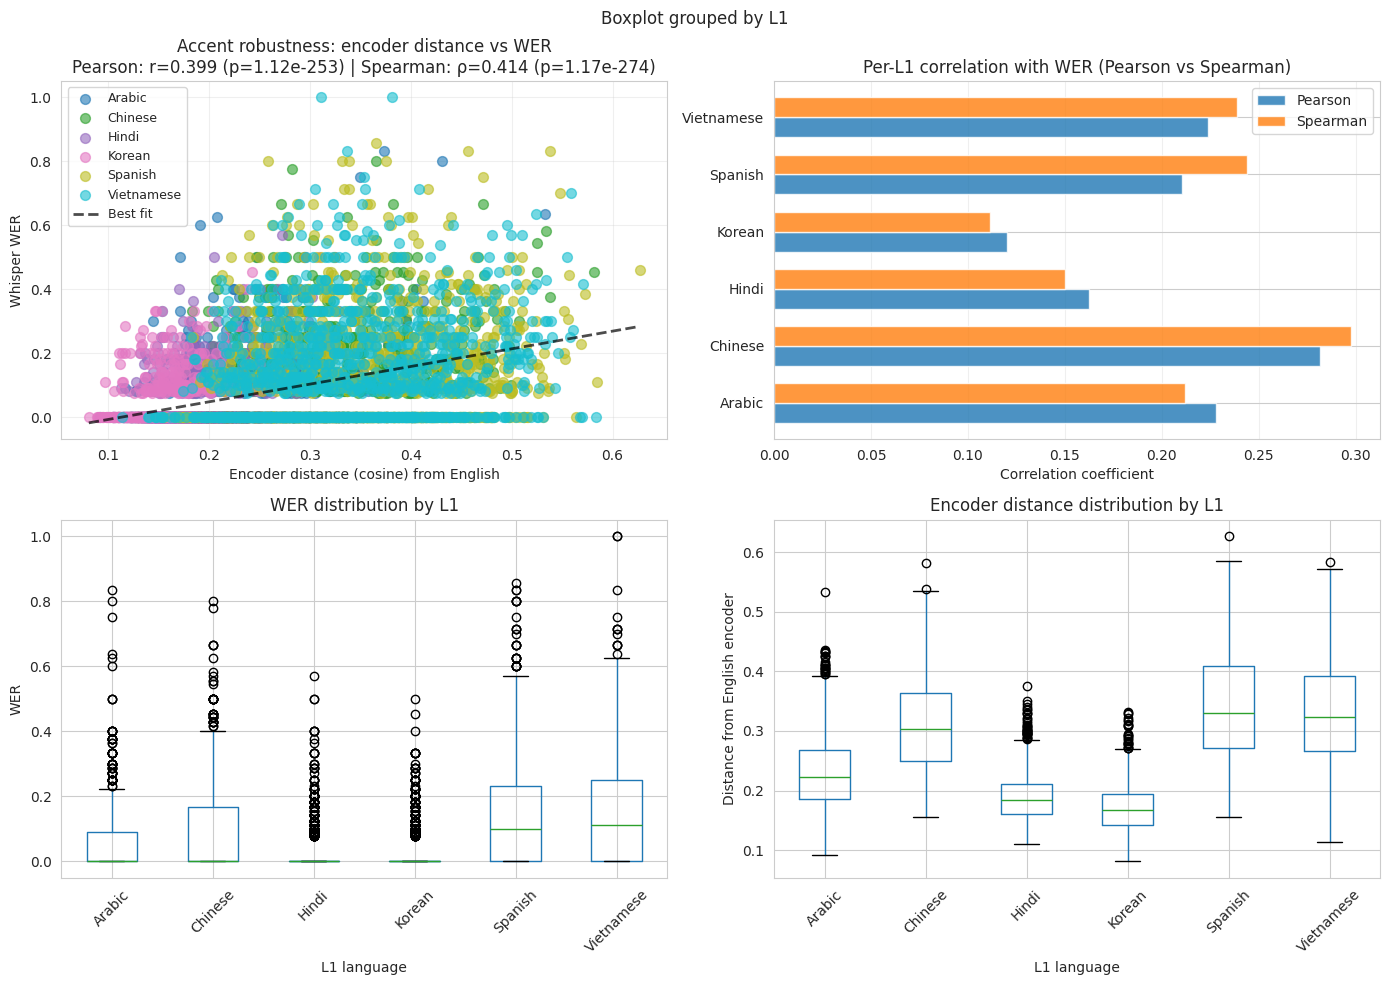

In [23]:
if len(valid_results) > 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Overall scatter plot (top-left)
    ax = axes[0, 0]
    colors = plt.cm.tab10(np.linspace(0, 1, len(valid_results["L1"].unique())))
    for i, l1 in enumerate(sorted(valid_results["L1"].unique())):
        subset = valid_results[valid_results["L1"] == l1]
        ax.scatter(subset["distance"], subset["wer"], label=l1, alpha=0.6, s=50, color=colors[i])
    
    # Add best-fit line
    z = np.polyfit(valid_results["distance"], valid_results["wer"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_results["distance"].min(), valid_results["distance"].max(), 100)
    ax.plot(x_line, p(x_line), "k--", alpha=0.7, linewidth=2, label="Best fit")
    
    ax.set_xlabel("Encoder distance (cosine) from English")
    ax.set_ylabel("Whisper WER")
    pearson_r, pearson_p = overall_corr["pearson"]
    spearman_r, spearman_p = overall_corr["spearman"]
    ax.set_title(f"Accent robustness: encoder distance vs WER\nPearson: r={pearson_r:.3f} (p={pearson_p:.2e}) | Spearman: ρ={spearman_r:.3f} (p={spearman_p:.2e})")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Distance distribution by L1 (top-right)
    ax = axes[1, 1]
    valid_results.boxplot(column="distance", by="L1", ax=ax)
    ax.set_xlabel("L1 language")
    ax.set_ylabel("Distance from English encoder")
    ax.set_title("Encoder distance distribution by L1")
    plt.sca(ax)
    plt.xticks(rotation=45)
    
    # WER distribution by L1 (bottom-left)
    ax = axes[1, 0]
    valid_results.boxplot(column="wer", by="L1", ax=ax)
    ax.set_xlabel("L1 language")
    ax.set_ylabel("WER")
    ax.set_title("WER distribution by L1")
    plt.sca(ax)
    plt.xticks(rotation=45)
    
    # Per-L1 correlation coefficients (bottom-right)
    ax = axes[0, 1]
    if per_l1_df is not None and len(per_l1_df) > 0:
        x = np.arange(len(per_l1_df))
        width = 0.35
        ax.barh(x - width/2, per_l1_df["pearson_r"], width, label="Pearson", alpha=0.8)
        ax.barh(x + width/2, per_l1_df["spearman_r"], width, label="Spearman", alpha=0.8)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        ax.set_yticks(x)
        ax.set_yticklabels(per_l1_df["L1"])
        ax.set_xlabel("Correlation coefficient")
        ax.set_title("Per-L1 correlation with WER (Pearson vs Spearman)")
        ax.grid(True, alpha=0.3, axis='x')
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center', va='center')
    
    plt.tight_layout()
    plt.savefig('src/analysis/results/e2_encoder_wer_correlation.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: src/analysis/results/e2_encoder_wer_correlation.png")
    plt.show()

✓ Saved: src/analysis/results/e2_per_l1_scatter.png


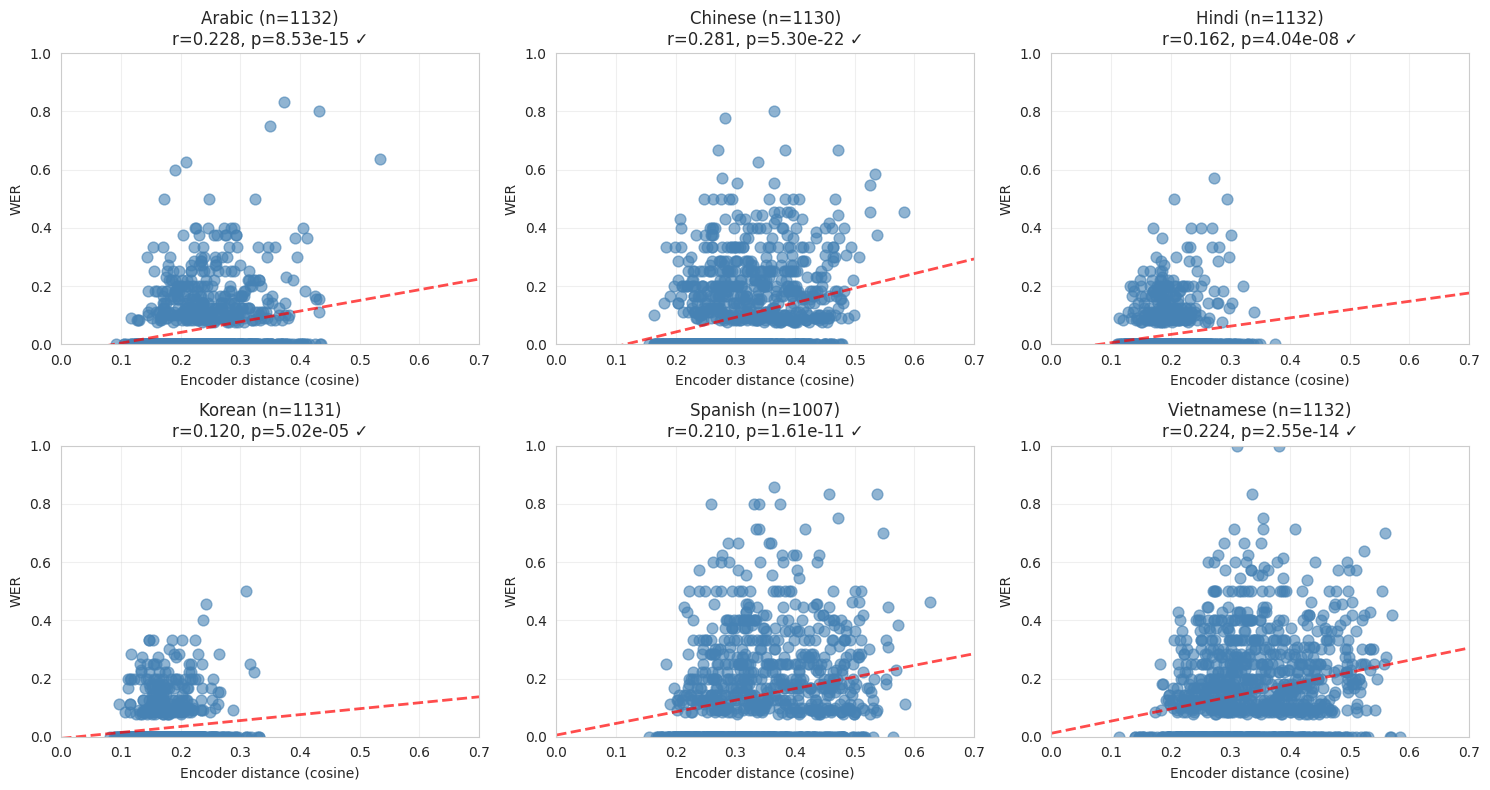

In [21]:
if len(valid_results) > 2:
    # Per-L1 scatter plots
    l1_list = sorted(valid_results["L1"].unique())
    n_l1 = len(l1_list)
    n_cols = 3
    n_rows = (n_l1 + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_l1 > 1 else [axes]
    
    for idx, l1 in enumerate(l1_list):
        ax = axes[idx]
        subset = valid_results[valid_results["L1"] == l1]
        
        # Scatter
        ax.scatter(subset["distance"], subset["wer"], alpha=0.6, s=60, color='steelblue')
        
        # Best-fit line for this L1
        if len(subset) > 2:
            z = np.polyfit(subset["distance"], subset["wer"], 1)
            p = np.poly1d(z)
            x_line = np.linspace(0, 0.7, 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=2)
            
            # Correlation stats
            corr_l1, pval_l1 = pearsonr(subset["distance"], subset["wer"])
            sig = "✓" if pval_l1 < 0.05 else "✗"
            ax.set_title(f"{l1} (n={len(subset)})\nr={corr_l1:.3f}, p={pval_l1:.2e} {sig}")
        else:
            ax.set_title(f"{l1} (n={len(subset)})")
        
        # Fixed scales for consistency
        ax.set_xlim(0, 0.7)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Encoder distance (cosine)")
        ax.set_ylabel("WER")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_l1, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('src/analysis/results/e2_per_l1_scatter.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: src/analysis/results/e2_per_l1_scatter.png")
    plt.show()

✓ Saved: src/analysis/results/e2_l1_aggregate.png

L1 aggregate statistics:
        L1  distance      wer
    Korean  0.171709 0.029361
     Hindi  0.189802 0.030696
    Arabic  0.232016 0.052332
   Chinese  0.310771 0.097564
Vietnamese  0.332817 0.151098
   Spanish  0.342493 0.142424


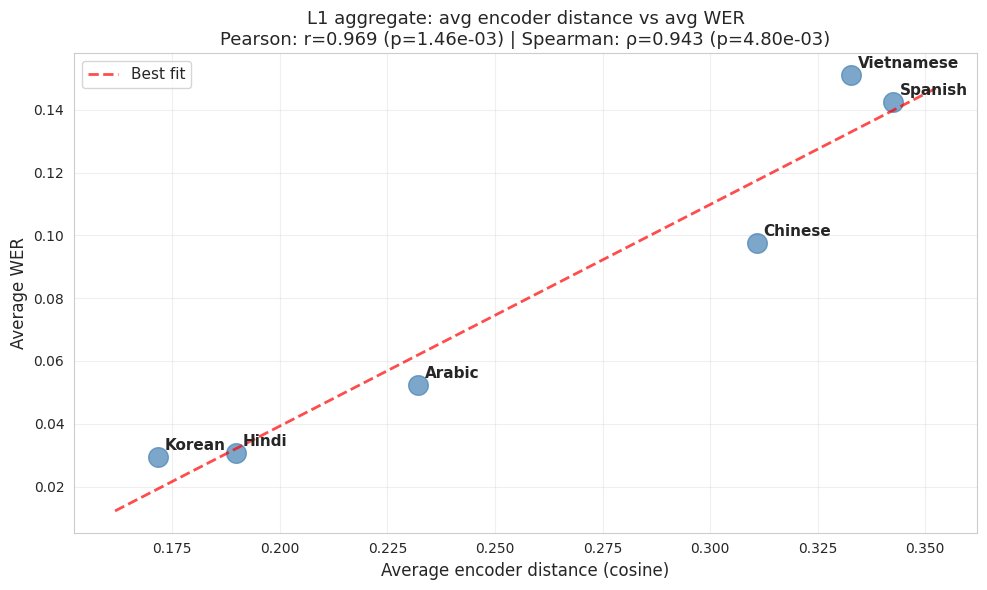

In [22]:
if len(valid_results) > 2:
    # Aggregate stats per L1
    l1_agg = valid_results.groupby("L1").agg({
        "distance": "mean",
        "wer": "mean",
    }).reset_index()
    l1_agg = l1_agg.sort_values("distance")
    
    # Calculate correlations at L1 level
    if len(l1_agg) > 2:
        pearson_agg, pearson_p_agg = pearsonr(l1_agg["distance"], l1_agg["wer"])
        spearman_agg, spearman_p_agg = spearmanr(l1_agg["distance"], l1_agg["wer"])
    else:
        pearson_agg = pearson_p_agg = spearman_agg = spearman_p_agg = np.nan
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(l1_agg["distance"], l1_agg["wer"], s=200, alpha=0.7, color='steelblue')
    
    # Add L1 labels
    for _, row in l1_agg.iterrows():
        ax.annotate(row["L1"], (row["distance"], row["wer"]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold')
    
    # Best-fit line
    if len(l1_agg) > 2:
        z = np.polyfit(l1_agg["distance"], l1_agg["wer"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(l1_agg["distance"].min() - 0.01, l1_agg["distance"].max() + 0.01, 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=2, label="Best fit")
    
    ax.set_xlabel("Average encoder distance (cosine)", fontsize=12)
    ax.set_ylabel("Average WER", fontsize=12)
    ax.set_title(f"L1 aggregate: avg encoder distance vs avg WER\nPearson: r={pearson_agg:.3f} (p={pearson_p_agg:.2e}) | Spearman: ρ={spearman_agg:.3f} (p={spearman_p_agg:.2e})", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('src/analysis/results/e2_l1_aggregate.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: src/analysis/results/e2_l1_aggregate.png")
    print(f"\nL1 aggregate statistics:")
    print(l1_agg.to_string(index=False))
    plt.show()

## Summary

In [ ]:
print("\n" + "="*70)
print("E2 ENCODER-WER CORRELATION ANALYSIS - SUMMARY")
print("="*70)
print(f"\nData:")
print(f"  Total utterance pairs: {len(results_df)}")
print(f"  With WER data: {len(valid_results)}")
print(f"  L1 speakers: {', '.join(sorted(valid_results['L1'].unique()))}")
print(f"  English reference: BDL (CMU speaker)")

print(f"\nHypothesis:")
print(f"  Accented speech has greater encoder distance from English,")
print(f"  which correlates with higher WER.")

if overall_corr and not np.isnan(overall_corr["pearson"][0]):
    print(f"\nResult (Overall):")
    pearson_r, pearson_p = overall_corr["pearson"]
    spearman_r, spearman_p = overall_corr["spearman"]
    print(f"  Pearson:  r={pearson_r:.3f} (p={pearson_p:.2e}) {'✓ SIGNIFICANT' if pearson_p < 0.05 else '✗ Not significant'}")
    print(f"  Spearman: ρ={spearman_r:.3f} (p={spearman_p:.2e}) {'✓ SIGNIFICANT' if spearman_p < 0.05 else '✗ Not significant'}")
    print(f"  Interpretation: {'✓ SUPPORTED' if (pearson_r > 0 and pearson_p < 0.05) else '✗ NOT SUPPORTED'}")
    
    if per_l1_df is not None:
        pearson_sig_count = (per_l1_df["pearson_p"] < 0.05).sum()
        spearman_sig_count = (per_l1_df["spearman_p"] < 0.05).sum()
        print(f"\n  Per-L1 significant correlations:")
        print(f"    Pearson:  {pearson_sig_count}/{len(per_l1_df)}")
        print(f"    Spearman: {spearman_sig_count}/{len(per_l1_df)}")
        print(f"\n  Per-L1 details:")
        for _, row in per_l1_df.iterrows():
            pearson_sig = "✓" if row["pearson_p"] < 0.05 else " "
            spearman_sig = "✓" if row["spearman_p"] < 0.05 else " "
            print(f"    {row['L1']:15s}:")
            print(f"      {pearson_sig} Pearson:  r={row['pearson_r']:7.3f}, p={row['pearson_p']:.2e}")
            print(f"      {spearman_sig} Spearman: ρ={row['spearman_r']:7.3f}, p={row['spearman_p']:.2e}")
else:
    print(f"\n[WARN] No WER data available for correlation analysis")

print("\n" + "="*70)

## Cell 8: Position-aligned Distance Analysis

Compare the distance metric used during **bridge training** (raw frame-position alignment) against the DTW-aligned metric above.

Two variants:
- `pos_all`: all 1500 frames — what the training-loop cosine-sim sanity check computes
- `pos_speech`: masked to `min(eng_speech_end, l2_speech_end)` frames — removes padding but keeps position alignment

This lets us answer:
1. How much does padding inflate `pos_all` vs the true signal?
2. Does position-aligned distance (speech-only) still correlate with WER at all?
3. Is the bridge training supervision (position-aligned) carrying any useful signal?

In [10]:
import pickle
from collections import defaultdict

POS_CACHE = Path(f"{ROOT}/src/analysis/results/encoder_wer_distances_position.pkl")

def position_aligned_distances(emb_eng_full, emb_l2_full, eng_speech_end, l2_speech_end):
    """
    Per-frame cosine distance under position alignment (no DTW).

    Uses normalised dot-product — O(T*D) instead of cdist's O(T²*D).

    Returns: pos_all, pos_speech, speech_frac
    """
    T = emb_eng_full.shape[0]

    eng_n = emb_eng_full / (np.linalg.norm(emb_eng_full, axis=-1, keepdims=True) + 1e-8)
    l2_n  = emb_l2_full  / (np.linalg.norm(emb_l2_full,  axis=-1, keepdims=True) + 1e-8)
    all_dists = 1.0 - (eng_n * l2_n).sum(axis=-1)   # [T]

    pos_all = float(all_dists.mean())

    if eng_speech_end is not None and l2_speech_end is not None:
        speech_end = min(int(eng_speech_end), int(l2_speech_end))
    elif eng_speech_end is not None:
        speech_end = int(eng_speech_end)
    elif l2_speech_end is not None:
        speech_end = int(l2_speech_end)
    else:
        speech_end = T

    speech_end = max(1, min(speech_end, T))
    pos_speech  = float(all_dists[:speech_end].mean())
    speech_frac = speech_end / T

    return pos_all, pos_speech, speech_frac


# Load cache or start fresh
if POS_CACHE.exists():
    with open(POS_CACHE, 'rb') as f:
        pos_results = pickle.load(f)
    print(f"✓ Loaded cached position-aligned results: {len(pos_results)} pairs")
    computed_pos = {(r["prompt_id"], r["L1"]) for r in pos_results}
else:
    pos_results = []
    computed_pos = set()
    print("Computing position-aligned distances from scratch...")

# Group by prompt so we load the English file once per prompt (not once per L1)
prompts_l1 = defaultdict(list)
for pid, l1_dict in valid_mapping.items():
    for l1, info in l1_dict.items():
        if l1 != "English" and (pid, l1) not in computed_pos:
            prompts_l1[pid].append((l1, info))

n_to_compute = sum(len(v) for v in prompts_l1.values())
print(f"  {n_to_compute} pairs to compute across {len(prompts_l1)} prompts")

errors_pos = {"missing": 0, "load": 0}

for prompt_id, l1_infos in tqdm(prompts_l1.items(), desc="Position distances"):
    eng_info = valid_mapping[prompt_id].get("English")
    if eng_info is None or not Path(eng_info["path"]).exists():
        errors_pos["missing"] += len(l1_infos)
        continue

    try:
        emb_eng = load_utterance(eng_info["path"])   # load ONCE per prompt
    except Exception:
        errors_pos["load"] += len(l1_infos)
        continue

    eng_speech_end = eng_info.get("speech_end_frame")

    for l1, speaker_info in l1_infos:
        if not Path(speaker_info["path"]).exists():
            errors_pos["missing"] += 1
            continue
        try:
            emb_l2 = load_utterance(speaker_info["path"])
        except Exception:
            errors_pos["load"] += 1
            continue

        pos_all, pos_speech, speech_frac = position_aligned_distances(
            emb_eng, emb_l2, eng_speech_end, speaker_info.get("speech_end_frame")
        )
        wer = wer_data.get((prompt_id, speaker_info["speaker"]), np.nan)
        pos_results.append({
            "prompt_id":    prompt_id,
            "L1":           l1,
            "speaker":      speaker_info["speaker"],
            "pos_dist_all":    pos_all,
            "pos_dist_speech": pos_speech,
            "speech_frac":     speech_frac,
            "wer":          wer,
        })

POS_CACHE.parent.mkdir(parents=True, exist_ok=True)
with open(POS_CACHE, 'wb') as f:
    pickle.dump(pos_results, f)

pos_df = pd.DataFrame(pos_results)
print(f"\n✓ {len(pos_df)} pairs  |  errors: {errors_pos}")

# Merge with DTW results
dtw_df = results_df[["prompt_id", "L1", "speaker", "distance", "wer"]].rename(columns={"distance": "dtw_dist"})
combined_df = dtw_df.merge(
    pos_df[["prompt_id", "L1", "speaker", "pos_dist_all", "pos_dist_speech", "speech_frac"]],
    on=["prompt_id", "L1", "speaker"], how="inner"
)
print(f"Merged: {len(combined_df)} pairs with all three distance types")
print(f"\n{'Metric':<24} {'mean':>7} {'std':>7} {'min':>7} {'max':>7}")
print("-" * 57)
for col, label in [
    ("dtw_dist",        "DTW (speech, aligned) "),
    ("pos_dist_speech", "Position (speech only)"),
    ("pos_dist_all",    "Position (all frames) "),
]:
    d = combined_df[col].dropna()
    print(f"{label:<24} {d.mean():7.4f} {d.std():7.4f} {d.min():7.4f} {d.max():7.4f}")
print(f"\nMean speech fraction: {combined_df['speech_frac'].mean():.2%} of 1500 frames")

✓ Loaded cached position-aligned results: 6664 pairs
  0 pairs to compute across 0 prompts


Position distances: 0it [00:00, ?it/s]


✓ 6664 pairs  |  errors: {'missing': 0, 'load': 0}
Merged: 6664 pairs with all three distance types

Metric                      mean     std     min     max
---------------------------------------------------------
DTW (speech, aligned)     0.2618  0.0970  0.0812  0.6268
Position (speech only)    0.4852  0.0782  0.1379  0.6469
Position (all frames)     0.0942  0.0332  0.0298  0.2766

Mean speech fraction: 8.98% of 1500 frames


## Cell 9: Correlation Comparison — DTW vs Position-aligned

Metric                      Pearson r      p-value  Spearman ρ      p-value  sig
--------------------------------------------------------------------------------
DTW (speech, aligned)           0.399    1.12e-253       0.414    1.17e-274  ✓
Position (speech only)          0.197     2.51e-59       0.208     3.59e-66  ✓
Position (all frames)           0.208     9.31e-66       0.251     1.40e-96  ✓

Per-L1 Spearman ρ:
  L1              DTW (speech, aligned)      Position (speech only)     Position (all frames)    
------------------------------------------------------------------------------------------------------
  Arabic          ✓ ρ=+0.212 (p=6e-13)       ✓ ρ=+0.097 (p=1e-03)       ✓ ρ=+0.139 (p=3e-06)     
  Chinese         ✓ ρ=+0.298 (p=2e-24)       ✓ ρ=+0.094 (p=1e-03)       ✓ ρ=+0.150 (p=4e-07)     
  Hindi           ✓ ρ=+0.150 (p=4e-07)         ρ=+0.048 (p=1e-01)       ✓ ρ=+0.119 (p=6e-05)     
  Korean          ✓ ρ=+0.111 (p=2e-04)       ✓ ρ=+0.067 (p=2e-02)       ✓ ρ=+0.141 (p=

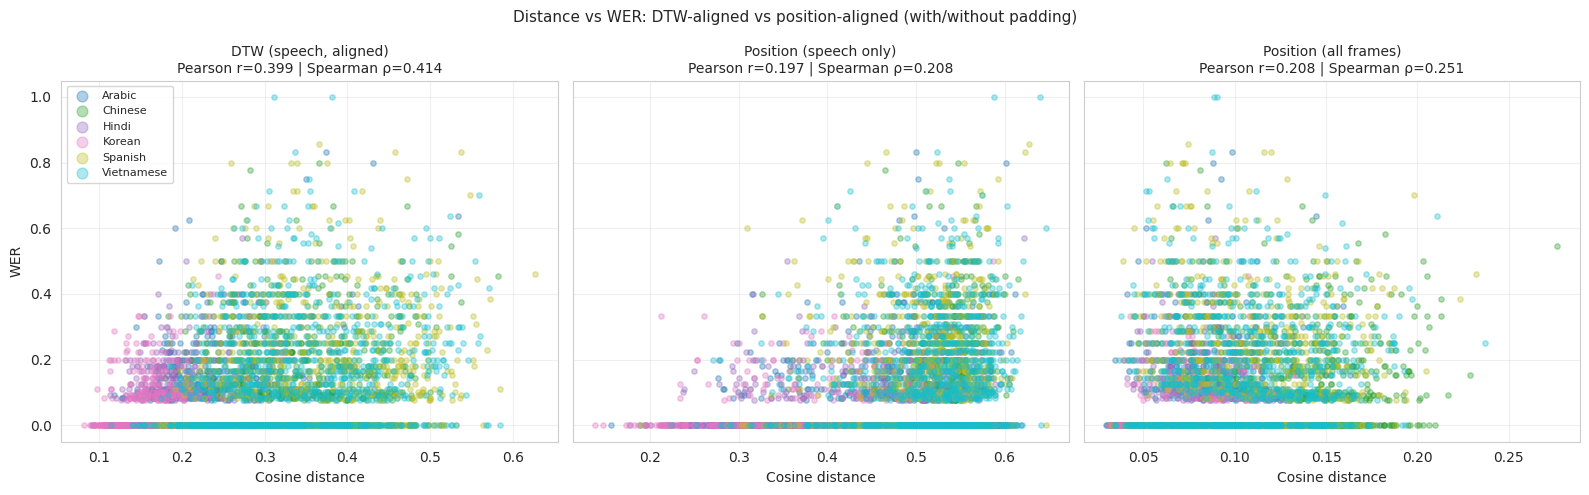

✓ Saved: src/analysis/results/e2_alignment_comparison_dist.png


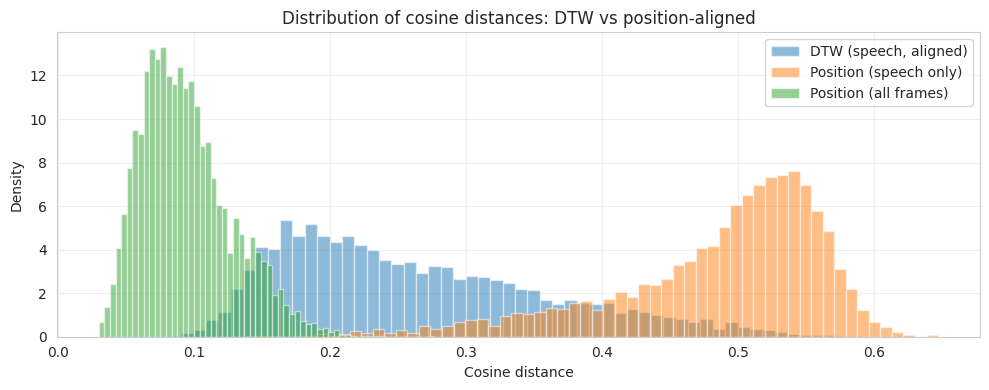

In [11]:
valid_combined = combined_df.dropna(subset=["wer"]).copy()

metrics = [
    ("dtw_dist",        "DTW (speech, aligned)"),
    ("pos_dist_speech", "Position (speech only)"),
    ("pos_dist_all",    "Position (all frames) "),
]

# ── Overall correlation table ──────────────────────────────────────────────
print(f"{'Metric':<26} {'Pearson r':>10} {'p-value':>12}  {'Spearman ρ':>10} {'p-value':>12}  sig")
print("-" * 80)
corr_summary = []
for col, label in metrics:
    sub = valid_combined.dropna(subset=[col])
    pr, pp = pearsonr(sub[col], sub["wer"])
    sr, sp = spearmanr(sub[col], sub["wer"])
    sig = "✓" if pp < 0.05 and sp < 0.05 else ("~" if pp < 0.05 or sp < 0.05 else "✗")
    print(f"{label:<26} {pr:>10.3f} {pp:>12.2e}  {sr:>10.3f} {sp:>12.2e}  {sig}")
    corr_summary.append({"metric": label.strip(), "pearson_r": pr, "spearman_r": sr,
                          "pearson_p": pp, "spearman_p": sp})

# ── Per-L1 Spearman ────────────────────────────────────────────────────────
print(f"\nPer-L1 Spearman ρ:")
header = f"  {'L1':<14}" + "".join(f"  {label.strip():<25}" for _, label in metrics)
print(header)
print("-" * (len(header) + 5))
for l1 in sorted(valid_combined["L1"].unique()):
    row_str = f"  {l1:<14}"
    for col, _ in metrics:
        sub = valid_combined[valid_combined["L1"] == l1].dropna(subset=[col])
        if len(sub) > 2:
            sr, sp = spearmanr(sub[col], sub["wer"])
            sig = "✓" if sp < 0.05 else " "
            row_str += f"  {sig} ρ={sr:+.3f} (p={sp:.0e})     "
        else:
            row_str += f"  {'n/a':<26}"
    print(row_str)

# ── Side-by-side scatter: distance vs WER for all three metrics ───────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
l1s = sorted(valid_combined["L1"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(l1s)))

for ax, (col, label) in zip(axes, metrics):
    sub = valid_combined.dropna(subset=[col])
    for i, l1 in enumerate(l1s):
        s = sub[sub["L1"] == l1]
        ax.scatter(s[col], s["wer"], label=l1, alpha=0.35, s=15, color=colors[i])
    pr, _ = pearsonr(sub[col], sub["wer"])
    sr, _ = spearmanr(sub[col], sub["wer"])
    ax.set_title(f"{label.strip()}\nPearson r={pr:.3f} | Spearman ρ={sr:.3f}", fontsize=10)
    ax.set_xlabel("Cosine distance")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("WER")
axes[0].legend(fontsize=8, markerscale=2)
plt.suptitle("Distance vs WER: DTW-aligned vs position-aligned (with/without padding)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{ROOT}/src/analysis/results/e2_alignment_comparison_scatter.png", dpi=150, bbox_inches="tight")
print(f"\n✓ Saved: src/analysis/results/e2_alignment_comparison_scatter.png")
plt.show()

# ── Distribution comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for col, label in metrics:
    ax.hist(valid_combined[col].dropna(), bins=60, alpha=0.5, label=label.strip(), density=True)
ax.set_xlabel("Cosine distance")
ax.set_ylabel("Density")
ax.set_title("Distribution of cosine distances: DTW vs position-aligned")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ROOT}/src/analysis/results/e2_alignment_comparison_dist.png", dpi=150, bbox_inches="tight")
print(f"✓ Saved: src/analysis/results/e2_alignment_comparison_dist.png")
plt.show()

## Cell 10: Per-L1 Breakdown — DTW vs Position-aligned

✓ Saved: src/analysis/results/e2_per_l1_alignment_scatter.png


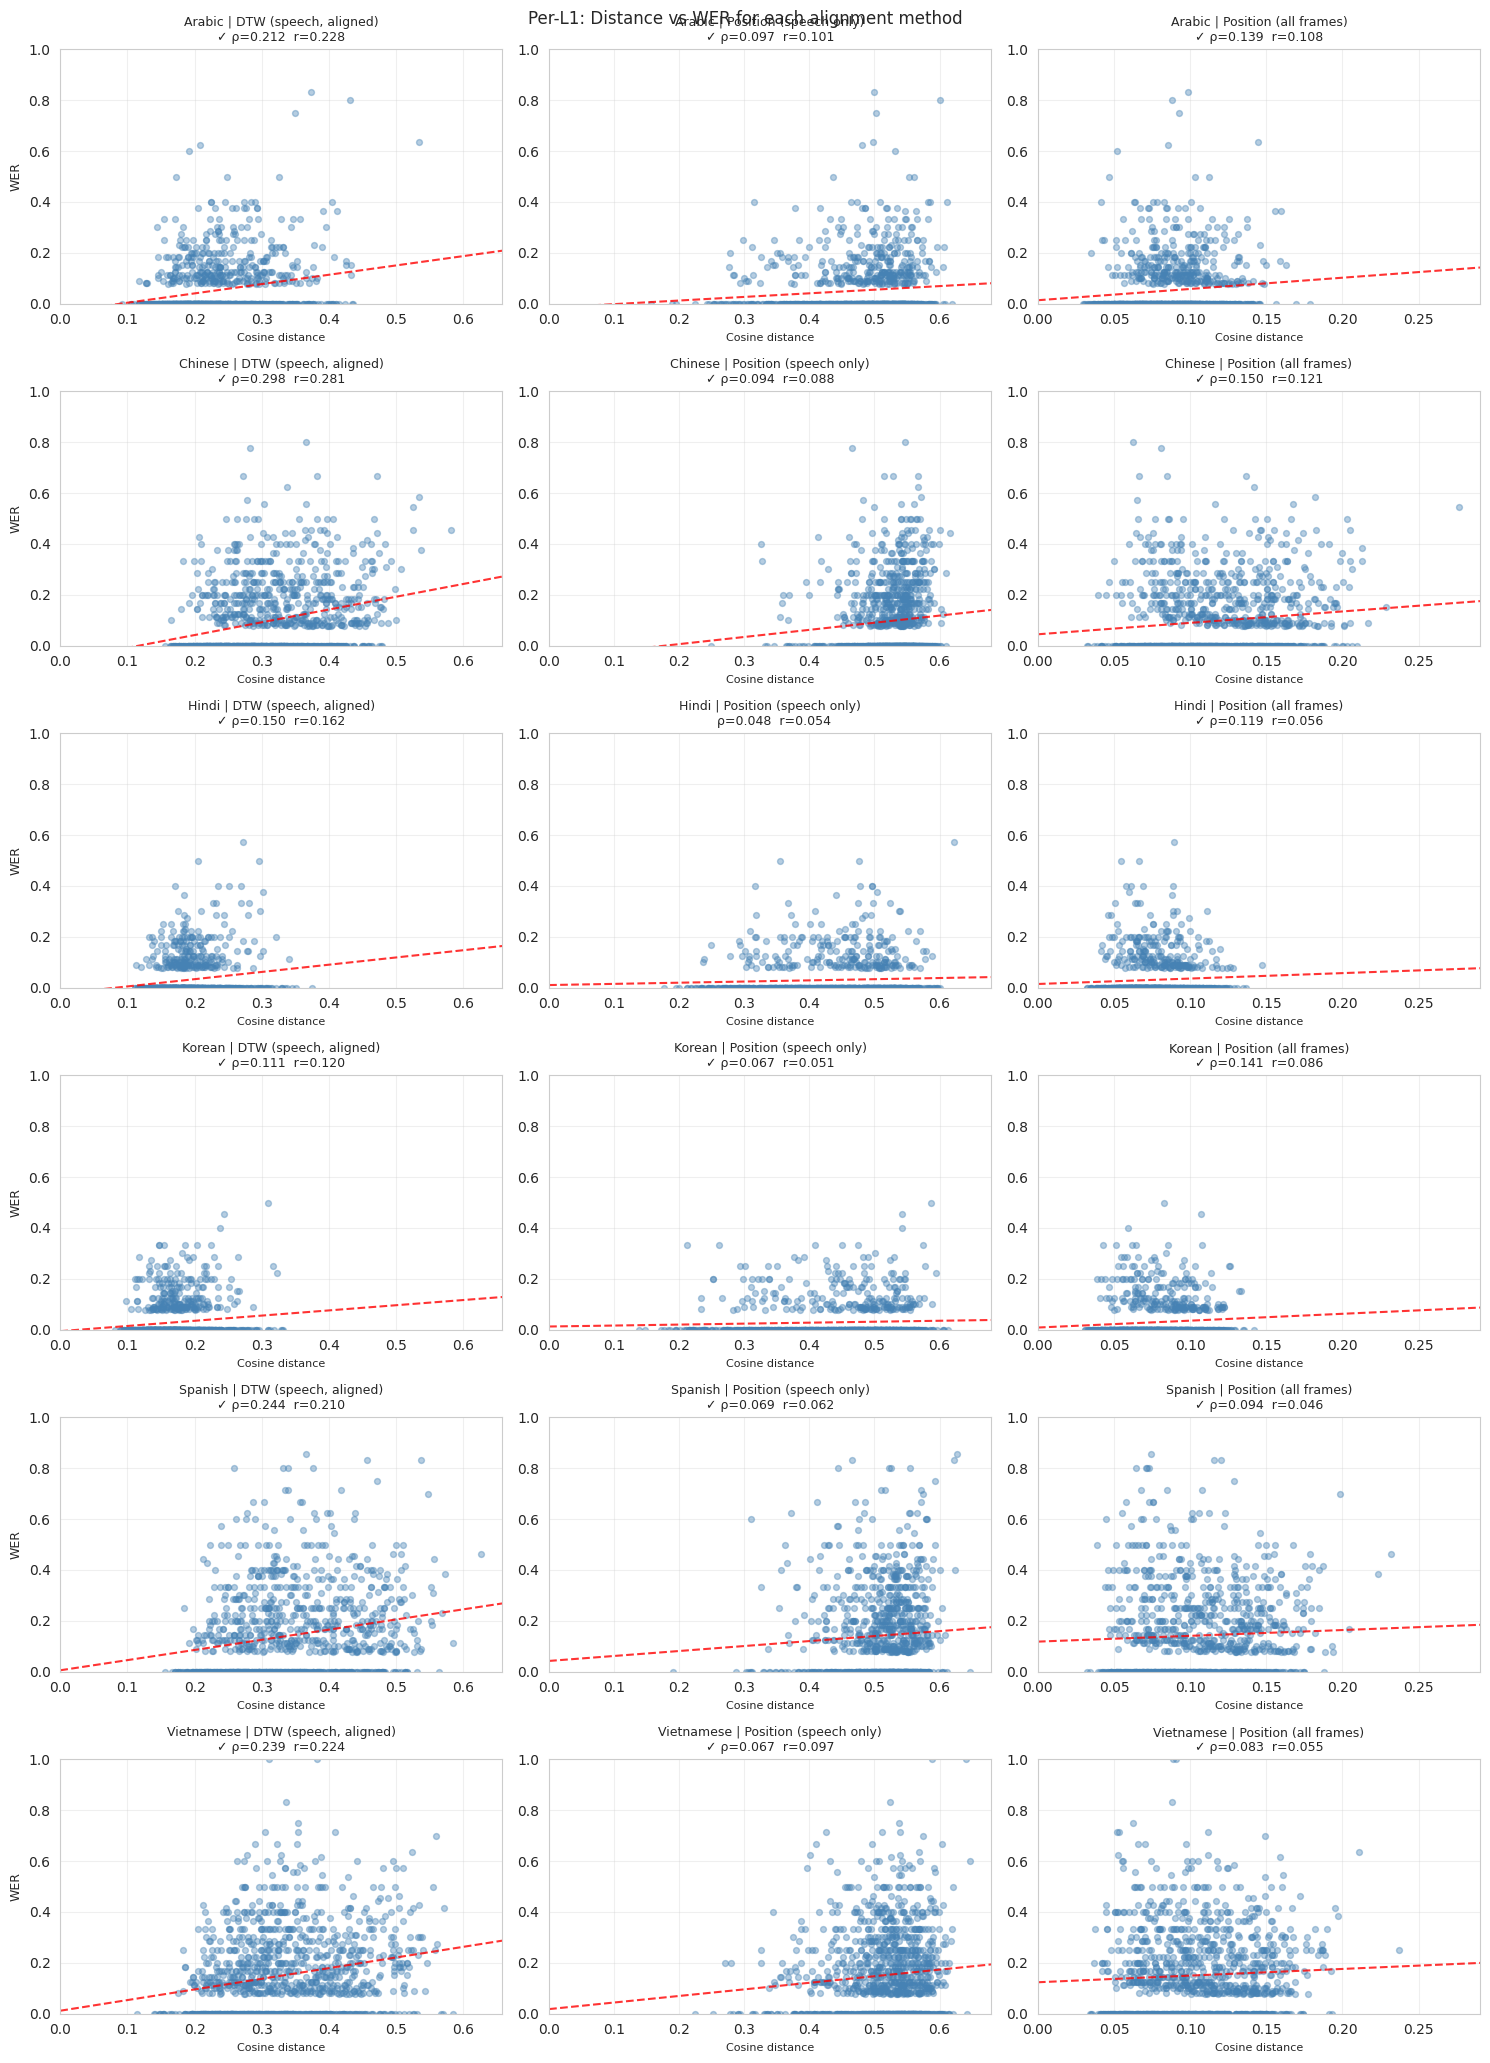

✓ Saved: src/analysis/results/e2_per_l1_alignment_dist.png


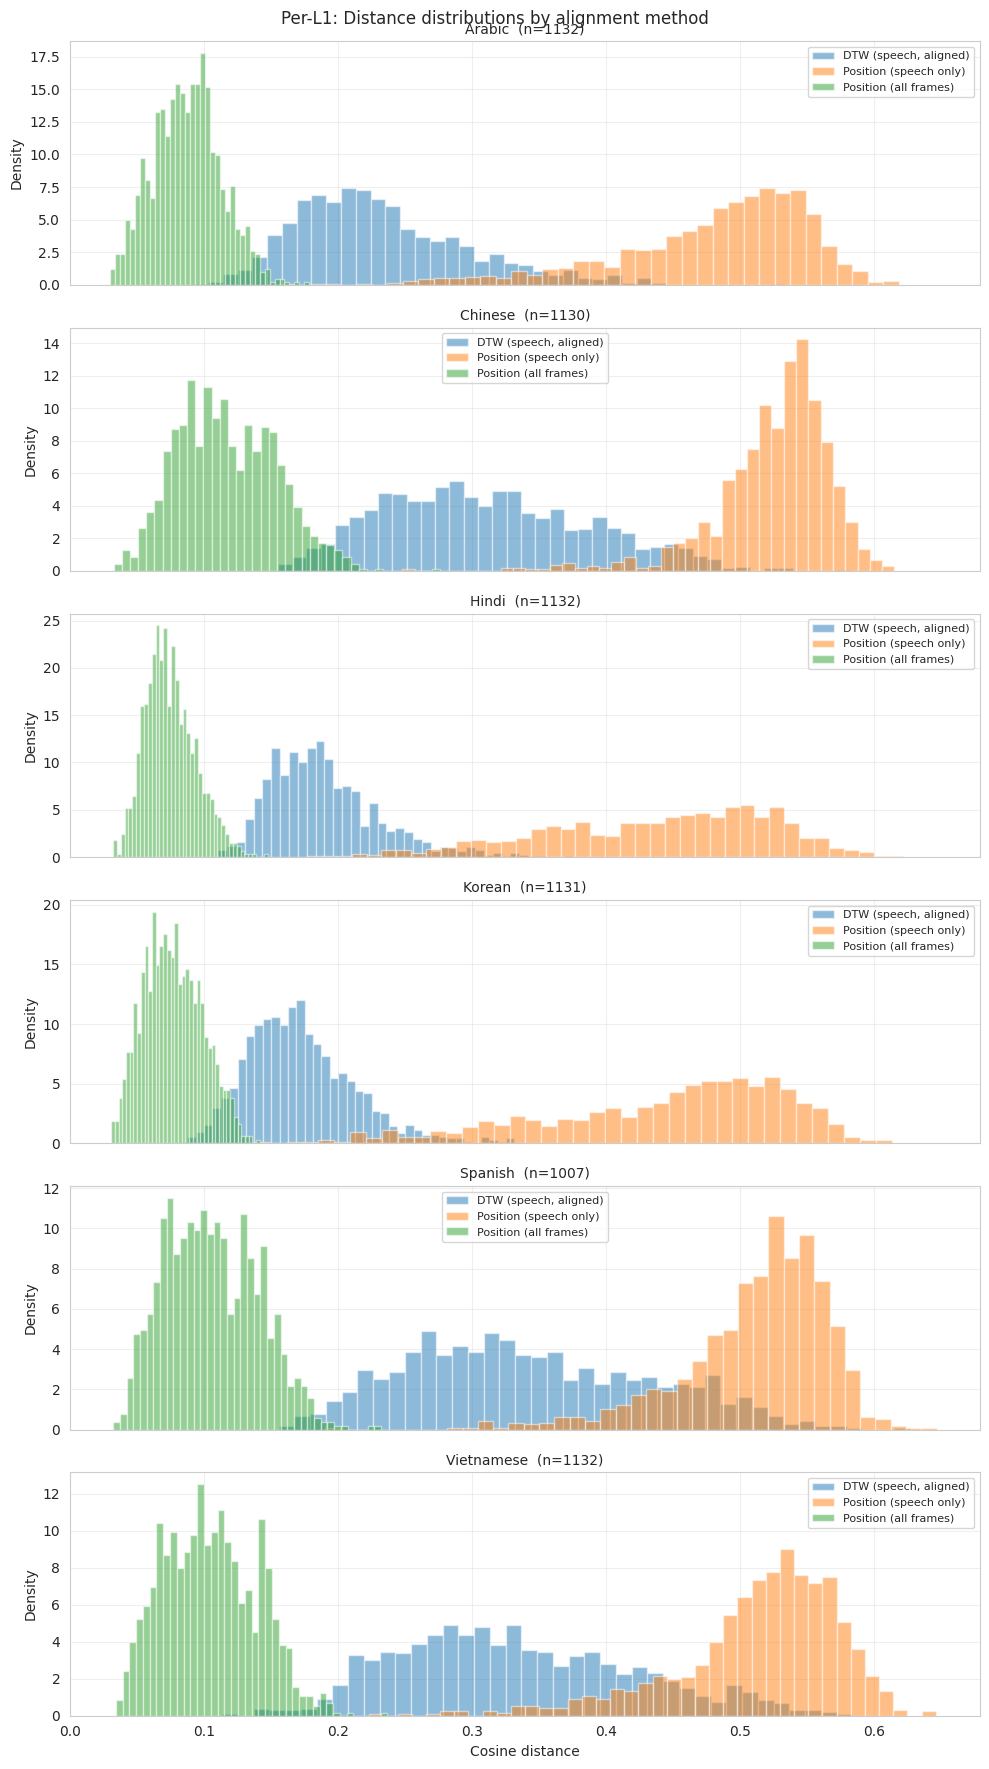

In [13]:
l1s = sorted(valid_combined["L1"].unique())
metrics = [
    ("dtw_dist",        "DTW (speech, aligned)"),
    ("pos_dist_speech", "Position (speech only)"),
    ("pos_dist_all",    "Position (all frames) "),
]
n_l1 = len(l1s)

# Global x limits per metric (same scale across all L1 rows for comparison)
x_lims = {
    col: (0, valid_combined[col].dropna().max() * 1.05)
    for col, _ in metrics
}

# ── Per-L1 scatter: one row per L1, one column per metric ─────────────────
fig, axes = plt.subplots(n_l1, 3, figsize=(15, 3.5 * n_l1))

for row, l1 in enumerate(l1s):
    sub = valid_combined[valid_combined["L1"] == l1]
    for col_idx, (metric_col, metric_label) in enumerate(metrics):
        ax = axes[row, col_idx]
        s = sub.dropna(subset=[metric_col])
        ax.scatter(s[metric_col], s["wer"], alpha=0.4, s=18, color="steelblue")

        if len(s) > 2:
            xlo, xhi = x_lims[metric_col]
            z = np.polyfit(s[metric_col], s["wer"], 1)
            x_fit = np.linspace(xlo, xhi, 100)
            ax.plot(x_fit, np.poly1d(z)(x_fit), "r--", linewidth=1.5, alpha=0.8)
            sr, sp = spearmanr(s[metric_col], s["wer"])
            pr, pp = pearsonr(s[metric_col], s["wer"])
            sig = "✓" if sp < 0.05 else " "
            ax.set_title(f"{l1} | {metric_label.strip()}\n{sig} ρ={sr:.3f}  r={pr:.3f}", fontsize=9)
        else:
            ax.set_title(f"{l1} | {metric_label.strip()}\nn/a", fontsize=9)

        ax.set_xlim(*x_lims[metric_col])
        ax.set_ylim(0, 1)
        ax.set_xlabel("Cosine distance", fontsize=8)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("WER", fontsize=9)

plt.suptitle("Per-L1: Distance vs WER for each alignment method", fontsize=12)
plt.tight_layout()
plt.savefig(f"{ROOT}/src/analysis/results/e2_per_l1_alignment_scatter.png", dpi=150, bbox_inches="tight")
print("✓ Saved: src/analysis/results/e2_per_l1_alignment_scatter.png")
plt.show()

# ── Per-L1 distance distributions (shared x axis across L1 rows) ──────────
x_global_max = max(valid_combined[col].dropna().max() for col, _ in metrics) * 1.05

fig, axes = plt.subplots(n_l1, 1, figsize=(10, 3 * n_l1), sharex=True)

for row, l1 in enumerate(l1s):
    ax = axes[row]
    sub = valid_combined[valid_combined["L1"] == l1]
    for metric_col, metric_label in metrics:
        d = sub[metric_col].dropna()
        ax.hist(d, bins=40, alpha=0.5, label=metric_label.strip(), density=True)
    ax.set_title(f"{l1}  (n={len(sub)})", fontsize=10)
    ax.set_xlim(0, x_global_max)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Cosine distance")
plt.suptitle("Per-L1: Distance distributions by alignment method", fontsize=12)
plt.tight_layout()
plt.savefig(f"{ROOT}/src/analysis/results/e2_per_l1_alignment_dist.png", dpi=150, bbox_inches="tight")
print("✓ Saved: src/analysis/results/e2_per_l1_alignment_dist.png")
plt.show()

## Cell 11: DTW Alignment Quality — Phoneme Agreement

For each aligned frame pair `(i, j)` in the DTW path, look up which phoneme frame `i` is in
the English TextGrid and which phoneme frame `j` is in the L2 TextGrid. If DTW is doing its
job, the labels should match far more often than chance or than position-based alignment.

**Quantitative:** phoneme agreement rate for DTW vs position-based, per L1 (sample of 30 utterances per L1).

**Visual:** warping path + phoneme boundary grid for a representative utterance per L1.

In [20]:
import random
from src.utils.textgrid import parse_textgrid

FPS = 50  # Whisper encoder frame rate

def load_phone_segments(info: dict) -> list:
    """Load phone segments from TextGrid or LAB file. Returns list of dicts with start/end/label in frames."""
    tg_path = info.get("textgrid")
    if not tg_path or not Path(tg_path).exists():
        return []
    try:
        if tg_path.endswith(".TextGrid"):
            segs = parse_textgrid(tg_path, tier_name="phones")
            return [{"start": int(s.start * FPS), "end": int(s.end * FPS), "label": s.label.upper().rstrip("012")} for s in segs]
        else:  # .lab
            segs = parse_lab_file(tg_path)
            return [{"start": int(s["start"] * FPS), "end": int(s["end"] * FPS), "label": s["label"].upper().rstrip("012")} for s in segs]
    except Exception:
        return []

def frames_to_phone_map(segs: list, n_frames: int) -> list:
    """Map each frame index [0, n_frames) to its phoneme label ('' = silence/unknown)."""
    phone_map = [""] * n_frames
    for seg in segs:
        lo = max(0, seg["start"])
        hi = min(n_frames, seg["end"])
        for f in range(lo, hi):
            phone_map[f] = seg["label"]
    return phone_map

def phoneme_agreement(path: list, map_eng: list, map_l2: list,
                      skip_silence: bool = True) -> float:
    """Frame-level: fraction of aligned pairs where both labels match."""
    matches, total = 0, 0
    for i, j in path:
        pe = map_eng[i] if i < len(map_eng) else ""
        pl = map_l2[j]  if j < len(map_l2)  else ""
        if skip_silence and (pe == "" or pl == ""):
            continue
        total += 1
        if pe == pl:
            matches += 1
    return matches / total if total > 0 else float("nan")

def phoneme_agreement_segmentwise(path: list, eng_segs: list, l2_segs: list,
                                   map_l2: list) -> float:
    """
    Segment-level: for each English phoneme segment, majority-vote on which L2
    phoneme the DTW path visits during that segment, then check against the
    canonical L2 label at the same index.

    This avoids penalising small boundary jitter — a 1-frame slip at a phoneme
    transition doesn't count as a full miss.
    """
    from collections import Counter

    # Build English-frame → [L2 frames] lookup from the path
    eng_to_l2 = {}
    for i, j in path:
        eng_to_l2.setdefault(i, []).append(j)

    n_pairs = min(len(eng_segs), len(l2_segs))
    matches, total = 0, 0
    for k in range(n_pairs):
        e_seg = eng_segs[k]
        l_seg = l2_segs[k]

        # Collect all L2 frames visited while traversing this English phoneme
        l2_visited = []
        for i in range(e_seg["start"], e_seg["end"]):
            l2_visited.extend(eng_to_l2.get(i, []))

        if not l2_visited:
            continue

        # Majority vote on which L2 phoneme label we land in
        l2_labels = [map_l2[j] for j in l2_visited
                     if j < len(map_l2) and map_l2[j] != ""]
        if not l2_labels:
            continue

        majority = Counter(l2_labels).most_common(1)[0][0]
        total += 1
        if majority == l_seg["label"]:
            matches += 1

    return matches / total if total > 0 else float("nan")

def build_frame_to_seg_idx(segs: list, max_frame: int) -> list:
    """Map each frame index to its phoneme segment index (-1 = not in any segment)."""
    frame_to_idx = [-1] * max_frame
    for k, seg in enumerate(segs):
        for f in range(max(0, seg["start"]), min(max_frame, seg["end"])):
            frame_to_idx[f] = k
    return frame_to_idx

def phoneme_agreement_window(path: list, eng_segs: list, l2_segs: list,
                              window: int = 1) -> float:
    """
    Segment-level: for each English phoneme k, check whether the DTW path
    majority-lands within ±window phoneme positions of l2_segs[k].

    e.g. window=1 on "C A T": if DTW maps English /k/ to L2 /ae/ (index k+1),
    that still counts as correct.
    """
    if not eng_segs or not l2_segs:
        return float("nan")

    max_l2 = max(s["end"] for s in l2_segs) + 1
    l2_frame_to_idx = build_frame_to_seg_idx(l2_segs, max_l2)

    eng_to_l2 = {}
    for i, j in path:
        eng_to_l2.setdefault(i, []).append(j)

    n_pairs = min(len(eng_segs), len(l2_segs))
    matches, total = 0, 0
    for k in range(n_pairs):
        e_seg = eng_segs[k]

        # Collect L2 segment indices visited during English segment k
        l2_indices = []
        for i in range(e_seg["start"], e_seg["end"]):
            for j in eng_to_l2.get(i, []):
                idx = l2_frame_to_idx[j] if j < max_l2 else -1
                if idx >= 0:
                    l2_indices.append(idx)

        if not l2_indices:
            continue

        from collections import Counter
        majority_idx = Counter(l2_indices).most_common(1)[0][0]
        total += 1
        if abs(majority_idx - k) <= window:
            matches += 1

    return matches / total if total > 0 else float("nan")


# ── Quantitative: agreement rates for a sample of utterances per L1 ───────
SAMPLE_PER_L1 = 30
random.seed(42)

quant_rows = []
sample_pairs = {}  # save one example per L1 for visualisation

for l1 in sorted(l for l in valid_mapping[next(iter(valid_mapping))].keys() if l != "English"):
    prompts_with_l1 = [pid for pid, d in valid_mapping.items() if l1 in d and "English" in d]
    sample_ids = random.sample(prompts_with_l1, min(SAMPLE_PER_L1, len(prompts_with_l1)))

    dtw_rates, pos_rates, dtw_seg_rates, pos_seg_rates = [], [], [], []
    dtw_win_rates, pos_win_rates = [], []
    for pid in tqdm(sample_ids, desc=f"{l1}", leave=False):
        eng_info = valid_mapping[pid]["English"]
        l2_info  = valid_mapping[pid][l1]

        eng_segs = load_phone_segments(eng_info)
        l2_segs  = load_phone_segments(l2_info)
        if not eng_segs or not l2_segs:
            continue

        eng_end = eng_info.get("speech_end_frame") or len(eng_segs[-1]["end"])
        l2_end  = l2_info.get("speech_end_frame")  or len(l2_segs[-1]["end"])

        try:
            emb_eng = load_utterance(eng_info["path"])[:eng_end]
            emb_l2  = load_utterance(l2_info["path"])[:l2_end]
        except Exception:
            continue

        map_eng = frames_to_phone_map(eng_segs, eng_end)
        map_l2  = frames_to_phone_map(l2_segs,  l2_end)

        # DTW agreement — frame-level, segment majority-vote, ±1-phoneme window
        path = dtw_ndim.warping_path(emb_eng, emb_l2)
        dtw_rate     = phoneme_agreement(path, map_eng, map_l2)
        dtw_rate_seg = phoneme_agreement_segmentwise(path, eng_segs, l2_segs, map_l2)
        dtw_rate_win = phoneme_agreement_window(path, eng_segs, l2_segs, window=1)

        # Position-based — same three variants
        min_len = min(eng_end, l2_end)
        pos_path     = list(zip(range(min_len), range(min_len)))
        pos_rate     = phoneme_agreement(pos_path, map_eng, map_l2)
        pos_rate_seg = phoneme_agreement_segmentwise(pos_path, eng_segs, l2_segs, map_l2)
        pos_rate_win = phoneme_agreement_window(pos_path, eng_segs, l2_segs, window=1)

        dtw_rates.append(dtw_rate)
        pos_rates.append(pos_rate)
        dtw_seg_rates.append(dtw_rate_seg)
        pos_seg_rates.append(pos_rate_seg)
        dtw_win_rates.append(dtw_rate_win)
        pos_win_rates.append(pos_rate_win)

        # Keep first valid pair per L1 for visualisation
        if l1 not in sample_pairs:
            sample_pairs[l1] = (pid, eng_info, l2_info, emb_eng, emb_l2,
                                map_eng, map_l2, eng_segs, l2_segs, path)

    quant_rows.append({
        "L1": l1,
        "dtw_frame":   np.nanmean(dtw_rates),
        "dtw_segment": np.nanmean(dtw_seg_rates),
        "dtw_window":  np.nanmean(dtw_win_rates),
        "pos_frame":   np.nanmean(pos_rates),
        "pos_segment": np.nanmean(pos_seg_rates),
        "pos_window":  np.nanmean(pos_win_rates),
        "n": len(dtw_rates),
    })

quant_df = pd.DataFrame(quant_rows)
cols = ["dtw_frame", "dtw_segment", "dtw_window", "pos_frame", "pos_segment", "pos_window"]
header = f"\n{'L1':<14}" + "".join(f"{c:>11}" for c in ["DTW frame","DTW seg","DTW ±1ph","Pos frame","Pos seg","Pos ±1ph"]) + "    n"
sep = "-" * (len(header) - 1)
print(header)
print(sep)
for _, row in quant_df.iterrows():
    vals = "".join(f"{row[c]:>11.3f}" for c in cols)
    print(f"{row['L1']:<14}{vals}  {row['n']}")
# Average row
print(sep)
avgs = "".join(f"{quant_df[c].mean():>11.3f}" for c in cols)
print(f"{'MEAN':<14}{avgs}")

Arabic:   0%|          | 0/30 [00:00<?, ?it/s]


L1              DTW frame    DTW seg   DTW ±1ph  Pos frame    Pos seg   Pos ±1ph    n
-------------------------------------------------------------------------------------
Arabic              0.259      0.283      0.950      0.156      0.171      0.420  30
Chinese             0.252      0.317      0.956      0.174      0.192      0.380  30
Hindi               0.195      0.214      0.963      0.189      0.222      0.644  30
Korean              0.228      0.233      0.965      0.268      0.294      0.611  30
Spanish             0.242      0.285      0.884      0.143      0.144      0.369  30
Vietnamese          0.244      0.293      0.894      0.141      0.173      0.389  30
-------------------------------------------------------------------------------------
MEAN                0.237      0.271      0.935      0.178      0.199      0.469


✓ Saved: src/analysis/results/e2_dtw_alignment_check.png


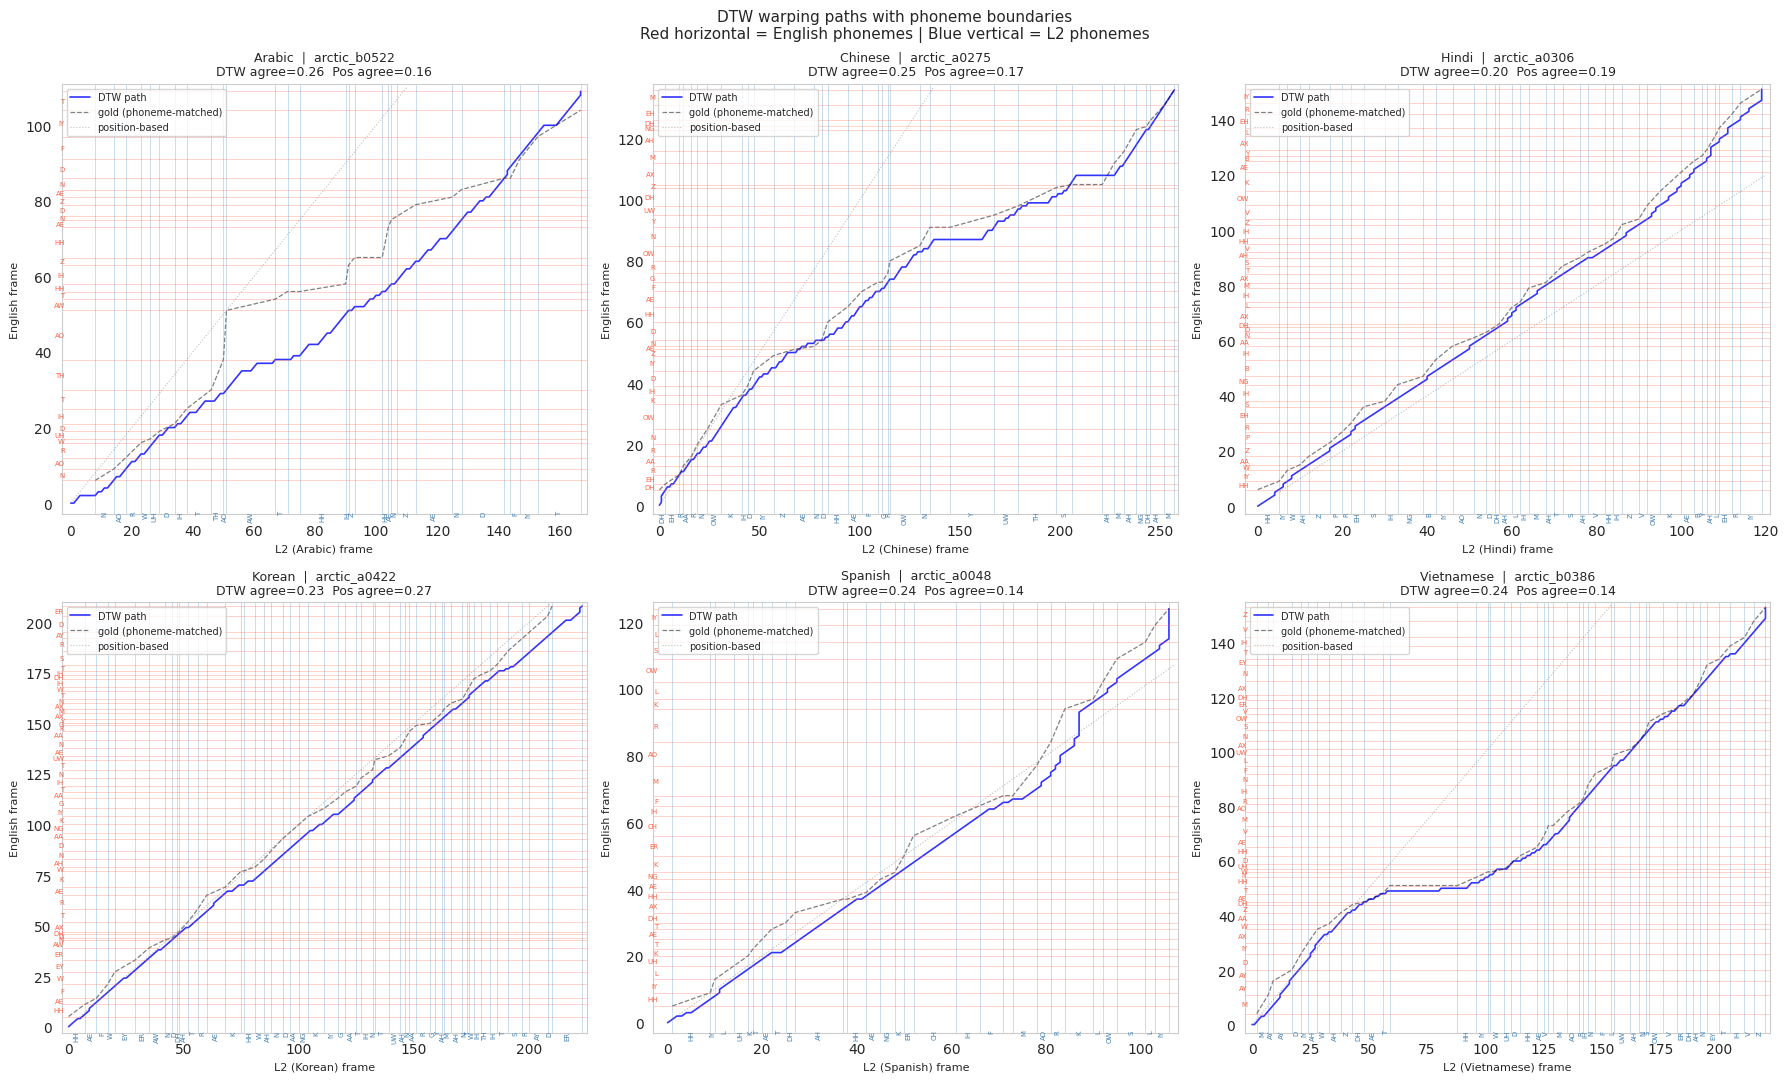

In [17]:
# ── Visual: warping path + phoneme grid, one example per L1 ───────────────
n_l1s = len(sample_pairs)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax_idx, (l1, data) in enumerate(sorted(sample_pairs.items())):
    if ax_idx >= len(axes):
        break
    pid, eng_info, l2_info, emb_eng, emb_l2, map_eng, map_l2, eng_segs, l2_segs, path = data
    ax = axes[ax_idx]

    path_arr = np.array(path)
    # x = L2 frames, y = English frames
    ax.plot(path_arr[:, 1], path_arr[:, 0], "b-", linewidth=1.2, alpha=0.8, label="DTW path")

    # Gold reference: connect corresponding phoneme pairs by index.
    # Both TextGrids use canonical labels for the same utterance, so
    # eng_segs[i] and l2_segs[i] are the same intended phoneme.
    # The ideal DTW path would thread through those matching cells.
    n_pairs = min(len(eng_segs), len(l2_segs))
    gold_x, gold_y = [], []
    for i in range(n_pairs):
        e, l = eng_segs[i], l2_segs[i]
        gold_x.extend([l["start"], l["end"]])   # L2 frames (x-axis)
        gold_y.extend([e["start"], e["end"]])   # English frames (y-axis)
    ax.plot(gold_x, gold_y, "k--", linewidth=0.9, alpha=0.5, label="gold (phoneme-matched)")

    # Position-based alignment: frame i aligned to frame i (up to shorter sequence)
    pos_len = min(len(map_eng), len(map_l2))
    ax.plot([0, pos_len], [0, pos_len], color="grey", linewidth=0.8, alpha=0.5,
            linestyle=":", label="position-based")

    # English phoneme boundaries (horizontal lines)
    eng_boundaries = sorted({seg["start"] for seg in eng_segs} | {seg["end"] for seg in eng_segs})
    for b in eng_boundaries:
        if 0 < b < len(map_eng):
            ax.axhline(b, color="tomato", linewidth=0.4, alpha=0.5)

    # L2 phoneme boundaries (vertical lines)
    l2_boundaries = sorted({seg["start"] for seg in l2_segs} | {seg["end"] for seg in l2_segs})
    for b in l2_boundaries:
        if 0 < b < len(map_l2):
            ax.axvline(b, color="steelblue", linewidth=0.4, alpha=0.5)

    # Phoneme labels along English axis (mid-point of each segment)
    for seg in eng_segs:
        mid = (seg["start"] + seg["end"]) / 2
        if mid < len(map_eng):
            ax.text(-2, mid, seg["label"], fontsize=5, ha="right", va="center", color="tomato")

    # Phoneme labels along L2 axis
    for seg in l2_segs:
        mid = (seg["start"] + seg["end"]) / 2
        if mid < len(map_l2):
            ax.text(mid, -2, seg["label"], fontsize=5, ha="center", va="top", color="steelblue", rotation=90)

    dtw_row = quant_df[quant_df["L1"] == l1]
    dtw_agr = dtw_row["dtw_agreement"].values[0] if len(dtw_row) else float("nan")
    pos_agr = dtw_row["pos_agreement"].values[0] if len(dtw_row) else float("nan")

    ax.set_xlabel(f"L2 ({l1}) frame", fontsize=8)
    ax.set_ylabel("English frame", fontsize=8)
    ax.set_title(f"{l1}  |  {pid}\nDTW agree={dtw_agr:.2f}  Pos agree={pos_agr:.2f}", fontsize=9)
    ax.set_xlim(-3, len(map_l2) + 1)
    ax.set_ylim(-3, len(map_eng) + 1)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(False)

# Hide unused axes
for ax in axes[n_l1s:]:
    ax.set_visible(False)

plt.suptitle(
    "DTW warping paths with phoneme boundaries\n"
    "Red horizontal = English phonemes | Blue vertical = L2 phonemes",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"{ROOT}/src/analysis/results/e2_dtw_alignment_check.png", dpi=150, bbox_inches="tight")
print("✓ Saved: src/analysis/results/e2_dtw_alignment_check.png")
plt.show()